# Detector-level centroiding and photon noise

**Scientific question.** How do centroid precision and the fraction of usable
measurements change as photons per sub-aperture frame increase? An inverse
square-root curve is a shot-noise reference, not a guaranteed fit to a detector
chain that also applies read noise and centroid-quality cuts.

The sensor, detector model, and centroider are installed `shwfs_ao` components.
The notebook reports precision conditional on the centroid being valid and
shows the validity fraction alongside it.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.modes import (
    normalize_mode_to_unit_pupil_rms,
    polar_pupil_coordinates,
    zernike_named_modes,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9
PHOTON_BUDGETS = (5e2, 1e3, 5e3, 2e4, 1e5)
N_REALIZATIONS = 12

## Configuration

In [3]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(64, 64),
    n_lenslets_across=8,
    min_fill_fraction=0.5,
)
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
pupil = geometry.pupil_geometry
rho, theta = polar_pupil_coordinates(pupil.x_m, pupil.y_m, TELESCOPE_DIAMETER_M)
modes = zernike_named_modes(rho, theta, geometry.pupil_mask)
static_opd_m = np.where(
    geometry.pupil_mask,
    40e-9 * normalize_mode_to_unit_pupil_rms(modes["astig_0"], geometry.pupil_mask),
    0.0,
)

## Simulation call

In [4]:
def noise_free_reference():
    sensor = build_detector_shack_hartmann_sensor(
        geometry,
        optics,
        DetectorConfig(photons_per_subap_frame=1e6),
        wfs_wavelength_m=WFS_WAVELENGTH_M,
        random_streams=NamedRandomStreams(SEED),
    )
    measurement = sensor.measure(
        static_opd_m, random_streams=NamedRandomStreams(SEED), include_noise=False
    )
    assert np.all(measurement.vector.valid_rows)
    return np.asarray(measurement.vector.values, dtype=float)

reference = noise_free_reference()

def centroid_precision(photons):
    squared_error_sum = 0.0
    valid_components = 0
    total_components = 0
    for realization in range(N_REALIZATIONS):
        sensor = build_detector_shack_hartmann_sensor(
            geometry,
            optics,
            DetectorConfig(photons_per_subap_frame=photons),
            wfs_wavelength_m=WFS_WAVELENGTH_M,
            random_streams=NamedRandomStreams(SEED + realization),
        )
        measurement = sensor.measure(
            static_opd_m,
            random_streams=NamedRandomStreams(SEED + realization),
            include_noise=True,
        )
        values = np.asarray(measurement.vector.values, dtype=float)
        valid = np.asarray(measurement.vector.valid_rows, dtype=bool)
        valid = valid & np.isfinite(values) & np.isfinite(reference)
        squared_error_sum += float(np.sum((values[valid] - reference[valid]) ** 2))
        valid_components += int(np.count_nonzero(valid))
        total_components += values.size
    rms_error = (np.sqrt(squared_error_sum / valid_components)
                 if valid_components else np.nan)
    return float(rms_error), valid_components / total_components, valid_components

precision_by_photons = {p: centroid_precision(p) for p in PHOTON_BUDGETS}

## Diagnostic table

In [5]:
photons = np.array(PHOTON_BUDGETS, dtype=float)
rms = np.array([precision_by_photons[p][0] for p in PHOTON_BUDGETS])
valid_fraction = np.array([precision_by_photons[p][1] for p in PHOTON_BUDGETS])
valid_components = np.array([precision_by_photons[p][2] for p in PHOTON_BUDGETS])
finite_indices = np.flatnonzero(np.isfinite(rms))
assert finite_indices.size > 0, "Need a finite measurement to anchor the reference."
anchor = int(finite_indices[0])
sqrt_law = rms[anchor] * np.sqrt(photons[anchor] / photons)
assert np.all(np.isnan(rms[valid_components == 0]))
assert np.all(np.isfinite(rms[valid_components > 0]))
assert np.all(np.isfinite(sqrt_law)) and np.all(sqrt_law > 0.0)
assert np.all((valid_fraction >= 0.0) & (valid_fraction <= 1.0))
print(f"Inverse-sqrt-N reference anchored at {photons[anchor]:g} photons.")
table = pd.DataFrame(
    {
        "photons per sub-aperture": photons.astype(int),
        "valid-component RMS error (px)": rms,
        "valid centroid-component fraction": valid_fraction,
        "valid centroid components": valid_components,
        "inverse-sqrt-N reference (px)": sqrt_law,
    }
)
table

Inverse-sqrt-N reference anchored at 1000 photons.


,photons per sub-aperture,valid-component RMS error (px),valid centroid-component fraction,valid centroid components,inverse-sqrt-N reference (px)
0,500,NaN,0.0,0,0.275241
1,1000,0.194624,1.0,1248,0.194624
2,5000,0.090640,1.0,1248,0.087039
3,20000,0.044227,1.0,1248,0.043519
4,100000,0.019610,1.0,1248,0.019462


## Plot

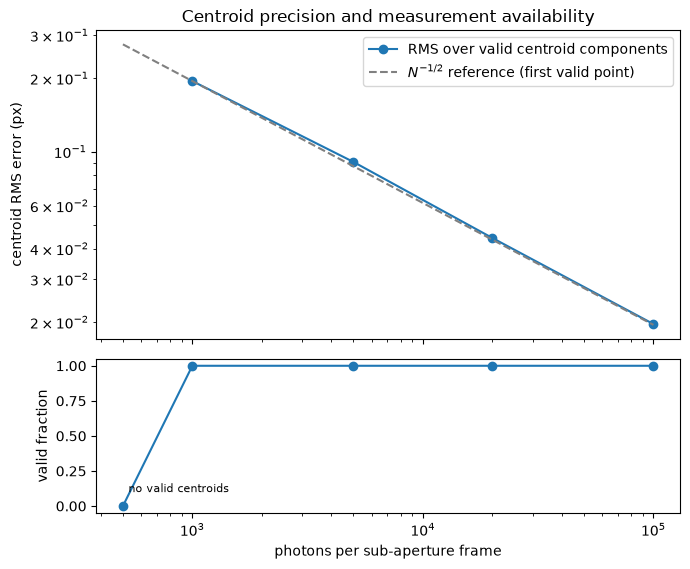

In [6]:
figure, (axis, validity_axis) = plt.subplots(
    2, 1, figsize=(7.0, 5.8), sharex=True, height_ratios=(2, 1)
)
axis.loglog(photons, rms, "o-", label="RMS over valid centroid components")
axis.loglog(photons, sqrt_law, "--", color="0.5",
            label=r"$N^{-1/2}$ reference (first valid point)")
axis.set_ylabel("centroid RMS error (px)")
axis.set_title("Centroid precision and measurement availability")
axis.legend()
validity_axis.semilogx(photons, valid_fraction, "o-")
validity_axis.set_xlabel("photons per sub-aperture frame")
validity_axis.set_ylabel("valid fraction")
validity_axis.set_ylim(-0.05, 1.05)
for photon_count in photons[valid_components == 0]:
    validity_axis.annotate("no valid centroids", (photon_count, 0.0),
                           xytext=(4, 10), textcoords="offset points", fontsize=8)
figure.tight_layout()
plt.show()

## Interpretation

The low-flux row with no valid centroids has an explicit NaN measured RMS: it
is a failed measurement, not a zero error. The inverse-square-root reference
is anchored to the first finite measured point, so that missing point does
not erase the reference curve. Errors use only centroid components accepted
by the detector's validity policy; the second plot shows the fraction used.

At low flux, those surviving measurements can be a selected subset of the
lenslets and realizations. Read noise, validity selection and finite sampling
can all produce departures from the reference curve. This short scan alone
does not establish a purely shot-noise-limited regime or a universal noise law.

## Limitations

- Detector read noise remains at its configured default.
- The RMS is pooled over valid components across all realizations; changing
  validity can change which measurements enter that statistic.
- A single static aberration is used; moving atmosphere adds temporal error.
- Twelve realizations make this a reproducible illustration rather than a
  precise estimate of the noise distribution.